In [1]:
import joblib

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths

paths = load_project_paths()

init_notebook()

In [2]:
class_colors = {
    "Aves": "#3B82F6",
    "Mammalia": "#F97316",
    "Amphibia": "#12843C",
    "Reptilia": "#EF4444",
    "Insecta": "#A855F7",
}

classes = list(class_colors.keys())
colors = [class_colors[c] for c in classes]

class_name_cmap = mcolors.ListedColormap(colors)

def balanced_group_sampling(y_class_name, n_per_group=1000, seed=42):
    rng = np.random.default_rng(seed)
    idx_all = []

    for g in np.unique(y_class_name):
        idx_g = np.where(y_class_name == g)[0]

        if len(idx_g) == 0:
            continue
        if len(idx_g) > n_per_group:
            chosen = rng.choice(idx_g, size=n_per_group, replace=False)
        else:
            chosen = idx_g  # keep all, no resampling

        idx_all.append(chosen)

    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)

    return idx_all

def fit_umap(run_name, reduced:bool):
    dataset = load_memmap_dataset(run_name=run_name, reduced=reduced, soundscape=False)
    le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
    le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

    y_class_name = le_class_name.inverse_transform(dataset.y[:, 0])
    y_primary_label = le_primary_label.inverse_transform(dataset.y[:, 1])

    idx = balanced_group_sampling(y_class_name=dataset.y[:, 0])

    X_sample = dataset.X[idx]
    y_sample = dataset.y[idx, 0]
    y_class_name_sample = y_class_name[idx]
    y_primary_label_sample = y_primary_label[idx]

    print(np.unique(y_class_name_sample, return_counts=True))

    model = umap.UMAP(n_neighbors=30, random_state=42, metric="euclidean", n_components=2)
    embeddings = model.fit_transform(X_sample)
    
    return embeddings, y_class_name_sample, y_primary_label_sample

def plot_umap_by_class(embeddings, target_class):
    """
    Plot UMAP/PCA embeddings for one class,
    coloring primary labels with a local palette derived from base class color.
    """

    mask = (y_class_name_sample == target_class)

    emb = embeddings[mask]
    labels = np.array(y_primary_label_sample)[mask]

    unique_labels = np.unique(labels)
    n = len(unique_labels)

    base_hex = class_colors[target_class]
    base_rgb = np.array(mcolors.to_rgb(base_hex))

    # create local palette by interpolating brightness
    # (keeps semantic class color identity but separates species)
    factors = np.linspace(0.4, 1.2, n)

    colors = []
    for f in factors:
        col = np.clip(base_rgb * f, 0, 1)
        colors.append(col)

    lut = dict(zip(unique_labels, colors))
    point_colors = np.array([lut[l] for l in labels])

    # plot
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=point_colors,
        s=8,
        alpha=0.8,
        edgecolors="none"
    )

    ax.set_title(f"{target_class} ({n} primary labels)")
    ax.set_xlim(embeddings[:, 0].min()-0.5, embeddings[:, 0].max()+0.5)
    ax.set_ylim(embeddings[:, 1].min()-0.5, embeddings[:, 1].max()+0.5)

    return fig

### 5 seconds chunks

In [3]:
run_name = "run_chunks_overlap"
embeddings, y_class_name_sample, y_primary_label_sample = fit_umap(run_name, reduced=True)

(array(['Amphibia', 'Aves', 'Insecta', 'Mammalia', 'Reptilia'],
      dtype=object), array([1000, 1000, 1000,  705,    2]))


/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


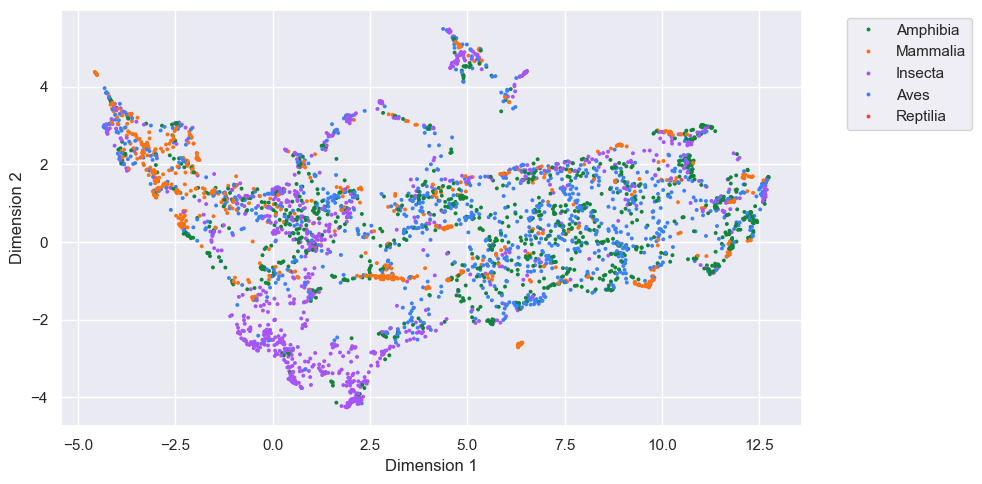

In [ ]:
fig = plt.figure(figsize=(8, 5))
ax=sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=y_class_name_sample,
    palette=class_colors,
    s=8,
    edgecolor="none",
)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")

plt.legend(loc="upper right")
plt.tight_layout()
fig.savefig(f"plots/umap/{run_name}_all.jpg", dpi=150, bbox_inches="tight")

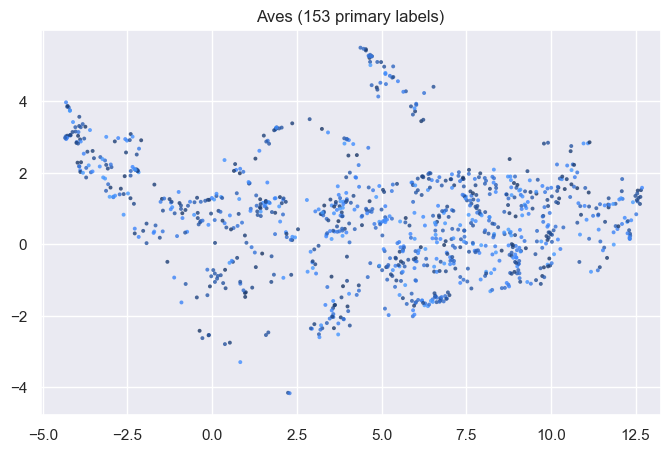

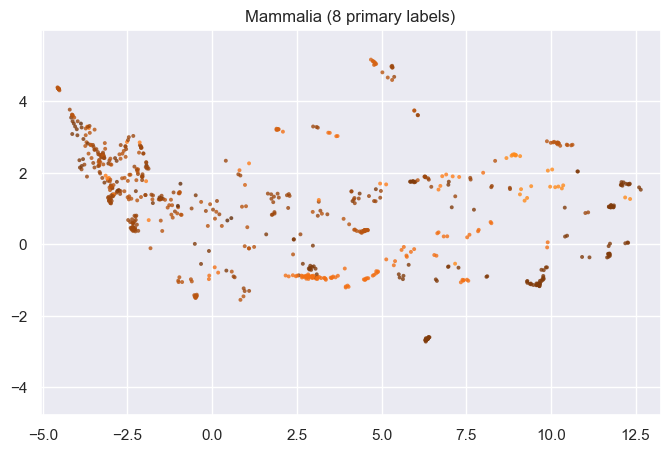

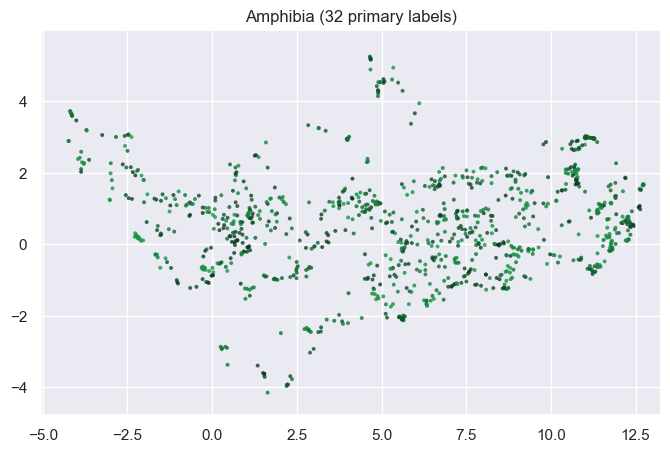

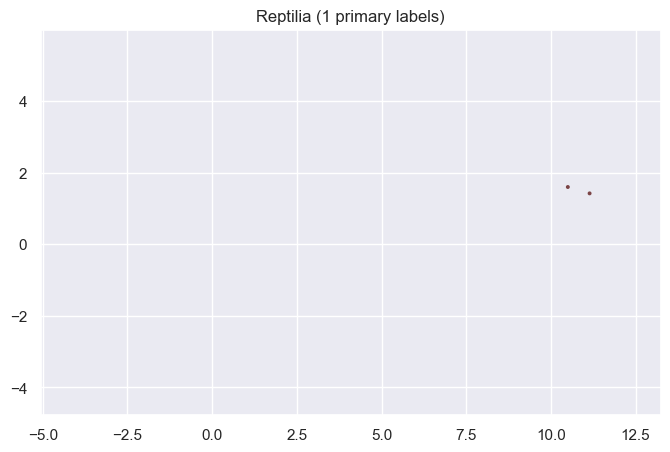

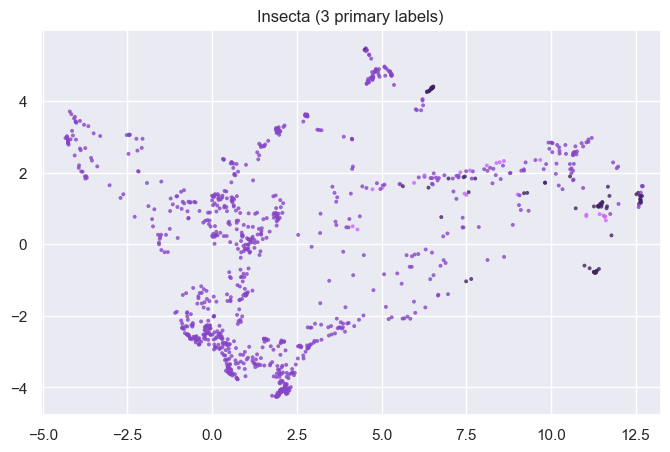

In [5]:
for class_name in class_colors.keys():
    fig = plot_umap_by_class(embeddings=embeddings, target_class=class_name)
    fig.savefig(f"plots/umap/{run_name}_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")

## MIL

In [6]:
run_name = "run_mil"
embeddings, y_class_name_sample, y_primary_label_sample = fit_umap(run_name, True)

(array(['Amphibia', 'Aves', 'Insecta', 'Mammalia', 'Reptilia'],
      dtype=object), array([1000, 1000, 1000, 1000,   13]))


/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


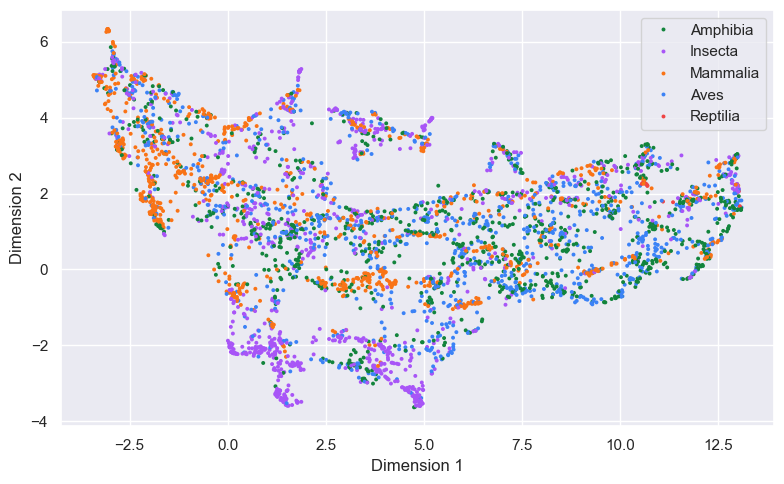

In [10]:
fig = plt.figure(figsize=(8, 5))
ax=sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=y_class_name_sample,
    palette=class_colors,
    s=8,
    edgecolor="none",
)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")

plt.legend(loc="upper right")
plt.tight_layout()
fig.savefig(f"plots/umap/{run_name}_all.jpg", dpi=150, bbox_inches="tight")

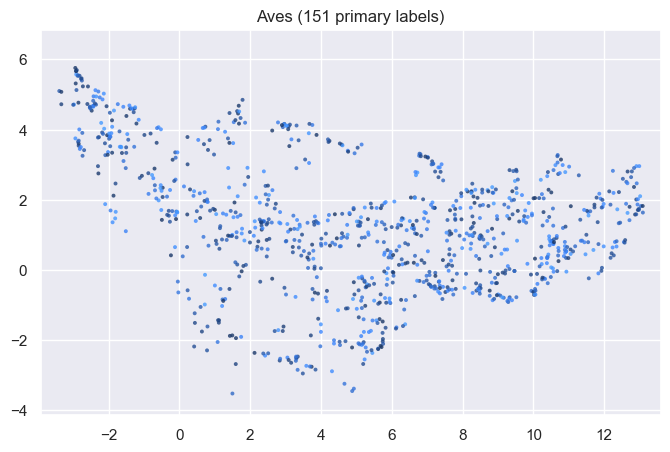

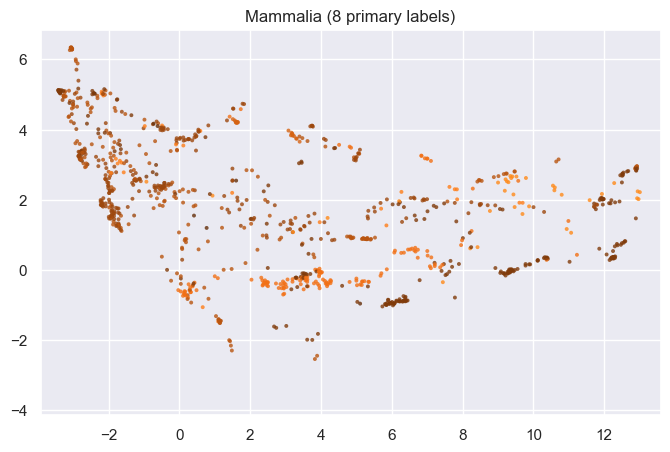

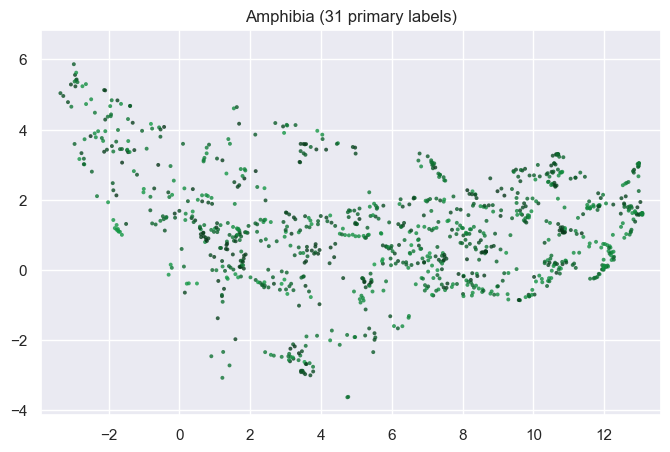

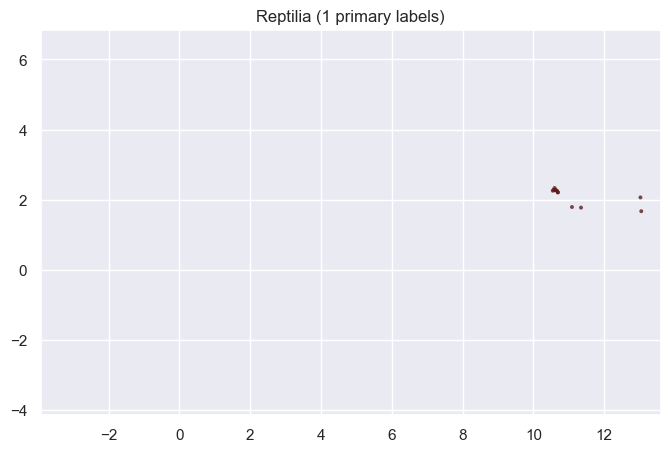

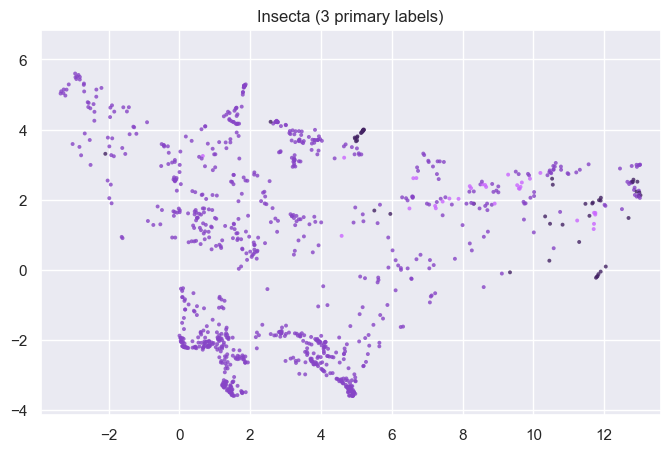

In [8]:
for class_name in class_colors.keys():
    fig = plot_umap_by_class(embeddings=embeddings, target_class=class_name)
    fig.savefig(f"plots/umap/{run_name}_{class_name.lower()}.jpg", dpi=150, bbox_inches="tight")